# Pipeline reproducible y calidad de datos

**Proyecto Final Henry · Dynamo Consultoría & Data Solutions**

Este notebook muestra cómo el proyecto pasa de los CSV crudos de Olist a la comparación de modelos con un solo comando, y documenta la calidad de los datos y las decisiones tomadas.

1. **Configuración**
2. **El pipeline:** qué hace cada paso
3. **Los datos:** la tabla de interacciones
4. **Calidad de datos:** faltantes, outliers y desbalance
5. **Features**
6. **Modelos:** comparación de resultados
7. **Reproducibilidad**
8. **Limitaciones e ideas**
9. **Conclusiones**

**Cómo usarlo:** por defecto lee los resultados guardados en `reports/`, así se ejecuta en segundos. Para recalcular todo desde cero, cambiar `EJECUTAR_PIPELINE = True` en la sección 2 (~7 minutos).


## 1. Configuración


In [18]:
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from src.config import INTERACTIONS_PATH, REPORTS_DIR

pd.set_option("display.width", 140)
AZUL, GRIS = "#2a78d6", "#b9b8b2"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.edgecolor": "#888"})
print("Raíz del proyecto:", ROOT)

Raíz del proyecto: c:\Users\denny\proyectos\dynamo-recsys-olist


## 2. El pipeline: qué hace cada paso

Todo el proyecto se ejecuta con un solo comando, `python -m src.pipeline`, que corre estos 5 pasos en orden. Cada paso usa lo que produjo el anterior, por eso el orden importa.

| Paso | Script | Recibe | Produce |
|---|---|---|---|
| 1. Datos crudos | `src/data/download_data.py` | — | 9 CSV de Olist en `data/raw/` |
| 2. Interacciones | `src/data/make_interactions.py` | Los 9 CSV | `data/processed/interactions.parquet` |
| 3. Calidad de datos | `src/data/data_quality.py` | `interactions.parquet` + clientes | `reports/dq_*.csv` |
| 4. Features | `src/data/feature_engineering.py` | `interactions.parquet` | `user_features.parquet`, `product_features.parquet` |
| 5. Modelos | `src/models/train_compare.py` | `interactions.parquet` | `reports/model_comparison.csv` |

**Por qué un script `.py` y no todo en el notebook:** el `.py` se puede automatizar (GitHub Actions, MLflow) y lo pueden importar la API y la demo. Este notebook solo lo ejecuta y muestra sus resultados.

**Dos decisiones de diseño:**
- La calidad de datos (paso 3) va **después** de las interacciones (paso 2), porque necesita `interactions.parquet`.
- Si un script todavía no existe en la rama, el pipeline lo marca como **saltado** y sigue, en lugar de romperse.

In [19]:
# Interruptor: False = usar resultados guardados (segundos) | True = recalcular todo (~7 min)
from datetime import datetime

EJECUTAR_PIPELINE = False

if EJECUTAR_PIPELINE:
    from src import pipeline
    pipeline.main()
else:
    print("Usando los resultados guardados en reports/. Archivos disponibles:\n")
    for archivo in sorted(REPORTS_DIR.glob("*.csv")):
        fecha = datetime.fromtimestamp(archivo.stat().st_mtime).strftime("%Y-%m-%d %H:%M")
        print(f"  {archivo.name:<32} actualizado: {fecha}")

Usando los resultados guardados en reports/. Archivos disponibles:

  baseline_results.csv             actualizado: 2026-10-08 16:33
  dq_cantidades.csv                actualizado: 2026-10-08 16:54
  dq_desbalance.csv                actualizado: 2026-10-08 16:54
  dq_faltantes.csv                 actualizado: 2026-10-08 16:54
  dq_nulos_disfrazados.csv         actualizado: 2026-10-08 16:54
  dq_outliers.csv                  actualizado: 2026-10-08 16:54
  model_comparison.csv             actualizado: 2026-10-08 17:00
  validation_recent_window.csv     actualizado: 2026-10-08 16:56


## 3. Los datos: la tabla de interacciones

El paso 2 une 6 de los 9 CSV de Olist en una sola tabla. **Cada fila es un producto dentro de un pedido:** si un cliente compra 2 unidades del mismo producto en un pedido, es una fila con `quantity = 2`; si vuelve a comprarlo en otro pedido, es otra fila.

In [20]:
df= pd.read_parquet(INTERACTIONS_PATH)

print(f"Filas (producto dentro de un pedido): {len(df):,}")
print(f"Clientes únicos:                      {df['customer_unique_id'].nunique():,}")
print(f"Productos únicos:                     {df['product_id'].nunique():,}")
print(f"Categorías:                           {df['category'].nunique()}")
print(f"Rango de fechas:                      {df['purchase_ts'].min():%Y-%m-%d} a {df['purchase_ts'].max():%Y-%m-%d}")
df.head()

Filas (producto dentro de un pedido): 101,953
Clientes únicos:                      94,983
Productos únicos:                     32,729
Categorías:                           74
Rango de fechas:                      2016-09-04 a 2018-09-03


,order_id,customer_unique_id,product_id,seller_id,purchase_ts,price,freight_value,quantity,review_score,category
0,2e7a8482f6fb09756ca50c10d7bfc047,b7d76e111c89f7ebf14761390f0f7d17,c1488892604e4ba5cff5b4eb4d595400,1554a68530182680ad5c8b042c3ab563,2016-09-04 21:15:19,39.99,31.67,1,1.0,furniture_decor
1,2e7a8482f6fb09756ca50c10d7bfc047,b7d76e111c89f7ebf14761390f0f7d17,f293394c72c9b5fafd7023301fc21fc2,1554a68530182680ad5c8b042c3ab563,2016-09-04 21:15:19,32.90,31.67,1,1.0,furniture_decor
2,bfbd0f9bdef84302105ad712db648a6c,830d5b7aaa3b6f1e9ad63703bec97d23,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-15 12:16:38,44.99,2.83,3,1.0,health_beauty
3,3b697a20d9e427646d92567910af6d57,32ea3bdedab835c3aa6cb68ce66565ef,3ae08df6bcbfe23586dd431c40bddbb7,522620dcb18a6b31cd7bdf73665113a9,2016-10-03 09:44:50,29.90,15.56,1,4.0,watches_gifts
4,be5bc2f0da14d8071e2d45451ad119d9,2f64e403852e6893ae37485d5fcacdaf,fd7fd78fd3cbc1b0a6370a7909c0a629,f09b760d23495ac9a7e00d29b769007c,2016-10-03 16:56:50,21.90,17.19,1,4.0,sports_leisure


## 4. Calidad de datos

El paso 3 del pipeline (`src/data/data_quality.py`) revisa 5 aspectos y guarda cada resultado en `reports/`. para cada uno se muestra el resultado y la decisión tomada .
**Criterio general:** un valor raro no es necesariamente un error . Antes de borrar o modificar algo, se busca una explicación de negocio.

In [21]:
faltantes= pd.read_csv(REPORTS_DIR / "dq_faltantes.csv")
disfrazados= pd.read_csv(REPORTS_DIR / "dq_nulos_disfrazados.csv")
outliers= pd.read_csv(REPORTS_DIR / "dq_outliers.csv")
cantidades= pd.read_csv(REPORTS_DIR / "dq_cantidades.csv")
desbalance= pd.read_csv(REPORTS_DIR / "dq_desbalance.csv")
print("5 reportes de calidad cargados.")

5 reportes de calidad cargados.


### 4.1 Valores faltantes

In [22]:
faltantes

,columna,nulos,pct_nulos
0,review_score,780,0.77
1,order_id,0,0.00
2,customer_unique_id,0,0.00
3,product_id,0,0.00
4,purchase_ts,0,0.00
5,seller_id,0,0.00
6,price,0,0.00
7,freight_value,0,0.00
8,quantity,0,0.00
9,category,0,0.00


**Resultado:** la única columna con nulos es `review_score`: 780 filas (0,77%), pedidos sin reseña. Coincide con lo que reporta el paso 2.

**Decisión:** se conservan. Un pedido sin reseña sigue siendo una compra válida y no se descarta. Las features de usuario y producto imputan esos nulos con el promedio general.


### 4.2 Nulos disfrazados

`check_missing` indica 0 nulos en `category`, pero el paso 2 rellenó los productos sin categoría con el texto `"unknown"`. El nulo sigue ahí, con otro nombre.

In [23]:
disfrazados

,columna,valor_relleno,filas,pct_filas,productos
0,category,unknown,1446,1.42,600


**Resultado:** 1.446 compras (1,42%) de 600 productos tienen categoría `"unknown"`. Afectan al doble de filas que los nulos reales de `review_score`, así que `check_missing` sola subestimaba el problema.

**Por qué 600 y no 610:** el catálogo tiene 610 productos sin categoría, pero 10 nunca se vendieron en un pedido válido, así que no aparecen en las interacciones.

**Decisión:** se conservan como `"unknown"`. Limitación documentada: para los modelos basados en categoría, esos productos parecen de "la misma categoría" aunque no lo sean.

### 4.3 Outliers en precio y flete (regla IQR)

Regla IQR: es outlier todo valor mayor que `Q3 + 1,5 × (Q3 − Q1)`.

In [24]:
outliers

,columna,q1,q3,limite_sup,n_outliers,pct_outliers,max
0,price,40.00,139.00,287.50,7632,7.49,6735.00
1,freight_value,13.15,21.22,33.32,10624,10.42,409.68


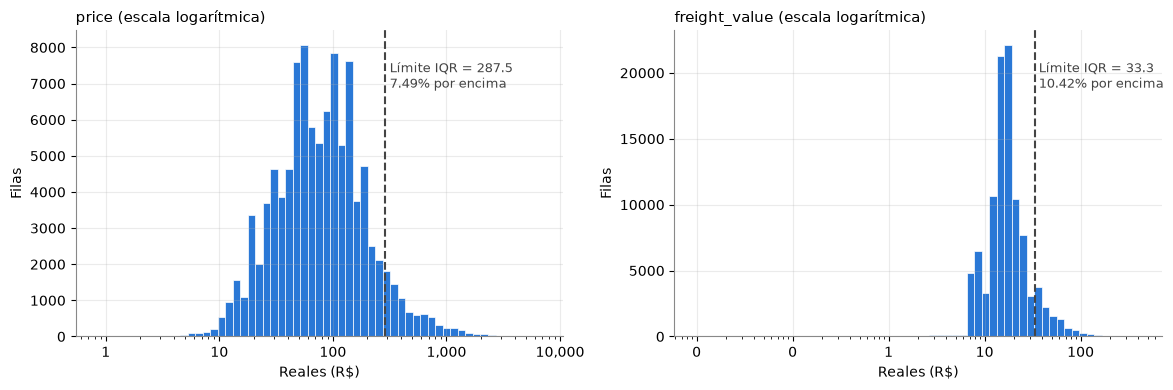

In [25]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (_, fila) in zip(axes, outliers.iterrows()):
    col, limite = fila["columna"], fila["limite_sup"]
    valores = df.loc[df[col] > 0, col]          # la escala log no admite ceros
    bins = np.logspace(np.log10(valores.min()), np.log10(valores.max()), 60)
    ax.hist(valores, bins=bins, color=AZUL, edgecolor="white", linewidth=0.5)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.axvline(limite, color="#444", linestyle="--", linewidth=1.5)
    ax.text(limite * 1.1, ax.get_ylim()[1] * 0.9,
            f"Límite IQR = {limite:,.1f}\n{fila['pct_outliers']}% por encima",
            fontsize=9, color="#444", va="top")
    ax.set_title(f"{col} (escala logarítmica)", loc="left", fontsize=11)
    ax.set_xlabel("Reales (R$)")
    ax.set_ylabel("Filas")
plt.tight_layout()
plt.show()

**Resultado:** la regla marca como outliers al 7,5% de los precios (sobre R$ 287,5) y al 10,4% de los fletes (sobre R$ 33,3). El gráfico muestra que la distribución tiene una **cola larga** que baja de forma continua, sin un grupo separado que indique errores de carga.

**Decisión:** se conservan. La regla IQR sirve para *detectar* valores altos, no para decidir si son errores: supone datos más o menos simétricos, y en e-commerce los precios tienen cola larga. Los precios altos corresponden a productos reales (electrodomésticos, muebles) y los fletes altos a productos grandes o envíos lejanos. Borrar el 10% de las ventas sería perder información real.

**Fletes en cero:** no se muestran en el gráfico (la escala logarítmica no admite ceros). Corresponden a envíos gratis por promoción, no a errores.

### 4.4 Cantidad de unidades por línea de pedido

La regla IQR no sirve acá: como más del 75% de las filas tiene `quantity = 1`, el IQR da 0 y cualquier compra de 2 unidades sería "outlier". Para una variable discreta y muy concentrada, se analiza la frecuencia de cada valor.

In [26]:
tramos = pd.cut(cantidades["quantity"], bins=[0, 1, 6, float("inf")],
                labels=["1 unidad", "2 a 6 unidades", "7 o más unidades"])
resumen_cantidades = (cantidades.groupby(tramos, observed=True)[["filas"]].sum()
                      .rename_axis("tramo").reset_index())
resumen_cantidades["pct"] = (resumen_cantidades["filas"] / resumen_cantidades["filas"].sum() * 100).round(2)
resumen_cantidades

,tramo,filas,pct
0,1 unidad,94904,93.09
1,2 a 6 unidades,7026,6.89
2,7 o más unidades,23,0.02


In [27]:
cantidades

,quantity,filas,pct
0,1,94904,93.09
1,2,5359,5.26
2,3,948,0.93
3,4,388,0.38
4,5,161,0.16
5,6,170,0.17
6,7,4,0.00
7,8,2,0.00
8,9,2,0.00
9,10,5,0.00


**Resultado:** el 93% de las líneas de pedido son de 1 unidad. De 2 a 6 unidades es habitual. A partir de 7 hay un corte natural: solo 23 filas en total (0,02%).

**Un detalle:** hay más compras de 6 unidades (170) que de 5 (161), cuando lo esperable sería que bajaran. Al filtrar por categoría, las compras de 6 se concentran en `housewares` (productos que se venden por media docena) y en `office_furniture` / `computers_accessories` (empresas equipando oficinas). Es evidencia orientativa: son 170 filas repartidas en varias categorías.

**Decisión:** se conservan. Son compras reales de mayoristas o empresas, y son muy pocas. Además, los modelos de popularidad cuentan **compradores distintos**, no unidades: una compra de 20 unidades pesa lo mismo que una de 1.



### 4.5 Desbalance: categorías y estados

In [28]:
desbalance

,variable,n_valores,pct_si_fuera_parejo,valor_top,pct_top,pct_top10,n_valores_menos_0.1pct
0,category (ventas),74,1.35,bed_bath_table,9.95,63.26,22
1,customer_state (clientes),27,3.70,SP,41.93,90.41,3


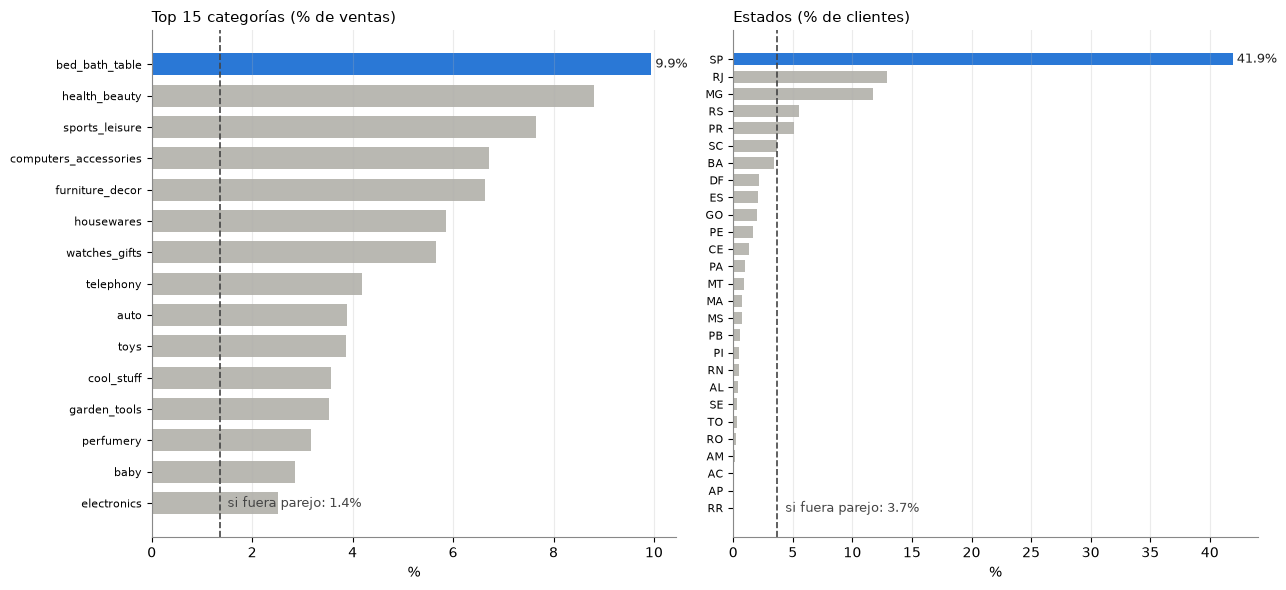

In [29]:
from src.data.data_quality import estado_por_cliente

pct_cat = df["category"].value_counts(normalize=True).mul(100)
pct_est = estado_por_cliente().value_counts(normalize=True).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
datos = [(axes[0], pct_cat.head(15), 100 / len(pct_cat), "Top 15 categorías (% de ventas)"),
         (axes[1], pct_est, 100 / len(pct_est), "Estados (% de clientes)")]
for ax, serie, parejo, titulo in datos:
    serie = serie[::-1]                       # invertir: la mayor queda arriba
    colores = [AZUL if i == len(serie) - 1 else GRIS for i in range(len(serie))]
    ax.barh(serie.index, serie.values, color=colores, height=0.7)
    ax.axvline(parejo, color="#444", linestyle="--", linewidth=1.2)
    ax.text(parejo, 0, f"  si fuera parejo: {parejo:.1f}%", fontsize=9, color="#444", va="center")
    ax.text(serie.values[-1], len(serie) - 1, f" {serie.values[-1]:.1f}%", va="center", fontsize=9, color="#222")
    ax.set_title(titulo, loc="left", fontsize=11)
    ax.set_xlabel("%")
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Resultado:**
- **Categorías:** con 74 categorías, un reparto parejo daría 1,35% a cada una. La primera (`bed_bath_table`) tiene 9,95%, y las 10 primeras concentran el 63% de las ventas. En el otro extremo, 22 categorías (casi un 30%) tienen menos del 0,1%.
- **Estados:** São Paulo concentra el 41,9% de los clientes, más de 10 veces lo que tendría con un reparto parejo (3,7%). Los 10 estados más grandes reúnen el 90%. Contando pedidos en vez de clientes únicos da casi lo mismo (~42%), así que el resultado es robusto.

**Decisión:** no se corrige: es una característica del negocio, no un error de los datos. Se documenta como limitación:
- Los modelos de popularidad recomiendan casi siempre productos de las categorías grandes, y las chicas casi nunca aparecen. Esto explica en parte la baja cobertura del baseline (0,04%).
- La popularidad general queda dominada por los gustos de São Paulo; un cliente de otro estado recibe, en la práctica, recomendaciones "paulistas".

### Resumen de calidad de datos

| Chequeo | Hallazgo | Decisión |
|---|---|---|
| Faltantes | `review_score`: 0,77% sin reseña | Se conservan; las features imputan con el promedio |
| Nulos disfrazados | `category = "unknown"`: 1,42% de las compras, 600 productos | Se conservan; limitación documentada |
| Outliers (IQR) | Precio 7,5% y flete 10,4% sobre el límite | Se conservan: cola larga real, no errores |
| Cantidad | 93% compra 1 unidad; 7+ unidades = 23 filas | Se conservan: compras de mayoristas o empresas |
| Desbalance | Top 10 categorías = 63% de ventas; SP = 41,9% de clientes | No se corrige: característica del negocio; limitación documentada |

**Conclusión:** no se eliminó ningún dato en esta etapa. La limpieza necesaria (pedidos cancelados, reseñas duplicadas, categorías vacías) ya la hace el paso 2. Este reporte documenta el estado de los datos y deja una base para el **monitoreo** del Sprint 2: si llegan datos nuevos, se puede comparar contra estos valores y detectar cambios.

## 5. Features

El paso 4 del pipeline (`src/data/feature_engineering.py`) genera variables agregadas por usuario y por producto, usando **solo datos anteriores al corte de entrenamiento** para evitar *data leakage*:

- **Usuario** (`user_`): órdenes, productos distintos, gasto total, precio promedio, reseña promedio, categorías, categoría favorita y recencia.
- **Producto** (`prod_`): compradores distintos, órdenes, unidades vendidas, precio promedio, reseña promedio y categoría.

> **Pendiente:** esta sección se completa con los datos cuando el PR #4 se integre a `main`. Hasta entonces, el pipeline marca este paso como "saltado".

## 6. Modelos: comparación de resultados

El paso 5 (`src/models/train_compare.py`) entrena y evalúa todos los modelos con el mismo protocolo: split temporal (train antes del 2018-06-01, test hasta el 2018-09-01) y las mismas métricas. Se muestran los resultados con **K = 10**, es decir, 10 recomendaciones por cliente.

In [30]:
modelos = pd.read_csv(REPORTS_DIR / "model_comparison.csv")
k10 = modelos[modelos["k"] == 10]
todos = k10[k10["segment"] == "all"].set_index("model")

tabla = k10.pivot(index="model", columns="segment", values="hit_rate@k")
tabla.columns = ["hit_rate@10_all", "hit_rate@10_warm"]
tabla["ndcg@10_all"] = todos["ndcg@k"]
tabla["cobertura_%"] = todos["coverage"] * 100
base = tabla.loc["pop_global (baseline)", "hit_rate@10_all"]
tabla["mejora_vs_baseline_%"] = (tabla["hit_rate@10_all"] / base - 1) * 100
tabla = tabla.sort_values("hit_rate@10_all")
tabla.round(4)

,hit_rate@10_all,hit_rate@10_warm,ndcg@10_all,cobertura_%,mejora_vs_baseline_%
model,,,,,
pop_global (baseline),0.0119,0.0103,0.0054,0.0412,0.0000
pop_categoria,0.0121,0.0207,0.0050,1.6732,1.8182
item2item_solo_cocompra,0.0135,0.0103,0.0056,1.9801,13.6364
pop_reciente_30d,0.0135,0.0103,0.0056,0.0412,13.6364
item2item_hibrido,0.0137,0.0207,0.0057,3.2864,15.4545


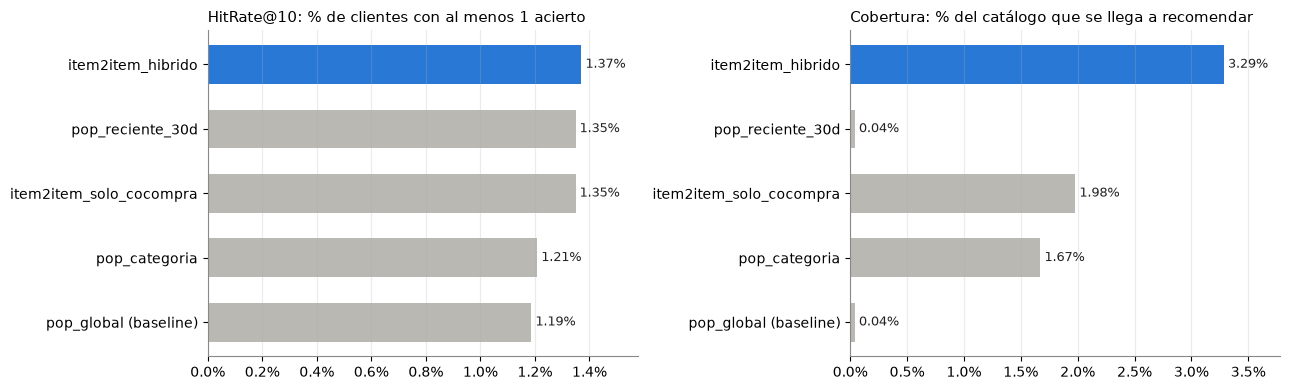

In [31]:
from matplotlib.ticker import PercentFormatter
tabla["hit_rate@10_all_%"] = tabla["hit_rate@10_all"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
metricas = [("hit_rate@10_all_%", "HitRate@10: % de clientes con al menos 1 acierto"),
            ("cobertura_%", "Cobertura: % del catálogo que se llega a recomendar")]
for ax, (col, titulo) in zip(axes, metricas):
    valores = tabla[col]
    colores = [AZUL if m == "item2item_hibrido" else GRIS for m in valores.index]
    ax.barh(valores.index, valores.values, color=colores, height=0.6)
    for i, v in enumerate(valores.values):
        ax.text(v, i, f" {v:.2f}%", va="center", fontsize=9, color="#222")
    ax.xaxis.set_major_formatter(PercentFormatter(decimals=1))
    ax.set_title(titulo, loc="left", fontsize=11)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.15)
plt.tight_layout()
plt.show()

**Modelo elegido: item-to-item híbrido** (`src/models/item_based.py`).

**Cómo leer los resultados**
-**En acierto, los modelos están casi empatados.** El híbrido mejora un 15% sobre el baseline (1,37% contra 1,19%), pero casi toda esa mejora viene de la popularidad reciente,  que obtiene 1,35%. ¿Por qué? porque el 98% de los clientes de test son nuevos, y a ellos ambos modelos les recomiendan lo mismo: lo más vendido en los últimos 30 días .
-**La diferencia real está en dos lugares:**
    -**Clientes con historial (`warm`):** el híbrido acierta el doble que el baseline (2,07% contra 1,03%). Con solo 387 clientes en ese grupo, la diferencia debe tomarse con cautela.
  - **Cobertura:** el híbrido recomienda el 3,3% del catálogo; los modelos de popularidad, el 0,04%. Es decir, 80 veces más variedad.

**Por qué los aciertos son bajos en términos absolutos:** acertar exige adivinar el producto exacto entre más de 32.000, y la gran mayoría de los clientes no tiene historial previo. El valor del modelo se mide en comparación con el baseline, no en números absolutos.

## 7. Reproducibilidad

Se coomparan los resultados obtenidos con los publicados en el README del repositorio. Si todos coinciden , el proceso es reproducible: otra persona, en otra computadora, obtiene los mismos números a partir de los mismos datos .

In [32]:
# Valores publicados en el README (datos y modelos, K = 10)
esperados = {
    "Filas de interacciones":            (101_953, len(df)),
    "Clientes únicos":                   (94_983, df["customer_unique_id"].nunique()),
    "Productos únicos":                  (32_729, df["product_id"].nunique()),
    "HitRate@10 baseline (all)":         (0.0119, tabla.loc["pop_global (baseline)", "hit_rate@10_all"]),
    "HitRate@10 híbrido (all)":          (0.0137, tabla.loc["item2item_hibrido", "hit_rate@10_all"]),
    "HitRate@10 híbrido (warm)":         (0.0207, tabla.loc["item2item_hibrido", "hit_rate@10_warm"]),
    "Cobertura híbrido (%)":             (3.29, tabla.loc["item2item_hibrido", "cobertura_%"]),
}

filas = []
for nombre, (esperado, obtenido) in esperados.items():
    decimales = 0 if isinstance(esperado, int) else len(str(esperado).split(".")[1])
    coincide = round(obtenido, decimales) == esperado
    filas.append({"métrica": nombre, "README": esperado,
                  "obtenido": round(obtenido, decimales), "coincide": "✅" if coincide else "❌"})

chequeo = pd.DataFrame(filas)
print(f"Coinciden {(chequeo['coincide'] == '✅').sum()} de {len(chequeo)}")
chequeo

Coinciden 7 de 7


,métrica,README,obtenido,coincide
0,Filas de interacciones,101953.0000,101953.0000,✅
1,Clientes únicos,94983.0000,94983.0000,✅
2,Productos únicos,32729.0000,32729.0000,✅
3,HitRate@10 baseline (all),0.0119,0.0119,✅
4,HitRate@10 híbrido (all),0.0137,0.0137,✅
5,HitRate@10 híbrido (warm),0.0207,0.0207,✅
6,Cobertura híbrido (%),3.2900,3.2900,✅


**Resultados:** Todos los valores coinciden con el README. Además, al volver a correr el pipeline, Git no detectó cambio en los CSV de `reports/`: los archivos generados son idénticos a los originales.

## 8. Limitaciones e ideas

### Limitaciones

| Limitación | Dato que la respalda | Consecuencia |
|---|---|---|
| **Cold start de clientes** | El 98% de los clientes del test no tiene compras previas | Para ellos solo se puede recomendar por popularidad |
| **Cold start de productos** | ~6.000 de 32.729 productos se venden por primera vez en el periodo de test | El modelo nunca los vio y no los puede recomendar |
| **Concentración geográfica** | São Paulo = 41,9% de los clientes | La popularidad general refleja sobre todo los gustos de SP |
| **Concentración de categorías** | Top 10 categorías = 63% de las ventas; 22 categorías con < 0,1% | Las categorías chicas casi nunca se recomiendan |
| **Categorías desconocidas** | 600 productos con `"unknown"` (1,42% de las compras) | Para los modelos por categoría, parecen todos de una misma categoría |
| **Muestra chica de clientes con historial** | Solo 387 clientes `warm` en el test | Las diferencias entre modelos en ese grupo pueden ser ruido |
| **Métrica exigente** | Un acierto requiere el producto exacto | Los valores absolutos de HitRate son bajos aunque el modelo funcione |

### Ideas para el Sprint 2

- **Popularidad por estado para clientes nuevos.** Hipótesis: recomendar lo más vendido en el estado del cliente puede acertar más que la popularidad general. Se debe validar con `evaluate()`. Riesgo: estados con muy pocos clientes generarían rankings poco confiables, por lo que convendría combinarla con la popularidad general.
- **Alarmas de calidad en el pipeline.** Convertir el reporte de calidad en controles automáticos: por ejemplo, detener el pipeline si los nulos de `review_score` superan un umbral o si aparecen precios negativos, antes de entrenar con datos defectuosos.
- **Automatización.** Ejecutar el pipeline y los tests con GitHub Actions en cada Pull Request, y registrar los experimentos con MLflow. El entrenamiento de modelos (~6,5 min) es el paso a optimizar.
- **Features con el corte de validación.** Si un modelo usa las features en la etapa de validación, deben recalcularse con el corte `VAL_START` para evitar *data leakage* (la función ya admite un parámetro `cutoff`).

## 9. Conclusiones

1. **El proyecto es reproducible.** Con un solo comando (`python -m src.pipeline`) se pasa de los CSV crudos a la comparación de modelos, y los resultados coinciden con los publicados.
2. **Los datos tienen buena calidad para el objetivo.** No se eliminó ningún registro en esta etapa: los valores extremos son reales (cola larga de precios y fletes, compras de mayoristas) y los faltantes son pocos y están identificados, incluidos los nulos "disfrazados".
3. **El desbalance es una característica del negocio, no un error.** La concentración en São Paulo y en pocas categorías se documenta como limitación de los modelos.
4. **El principal desafío es el cold start.** Casi todos los clientes son nuevos, por lo que mejorar las recomendaciones para ellos es la oportunidad de mayor impacto.
5. **El modelo elegido es el item-to-item híbrido:** iguala o supera al resto en acierto, duplica el acierto en clientes con historial y recomienda 80 veces más variedad de productos que la popularidad.